# BUSINESS DATA ANALYTICS APPLIED LAB #2: RISK MANAGEMENT & OSH ANALYTICS

Un conglomerado de 150 empresas está alarmado por el aumento en los reportes de accidentes laborales. El costo de las incapacidades y el impacto humano están afectando la productividad global. La gerencia no solo necesita saber cuántos accidentes ocurren, sino que requiere identificar patrones de riesgo para implementar una estrategia de prevención. Su misión como analista de datos consiste en aplicar la metodología CRISP-DM para consolidar fuentes de datos dispersas, generar evidencia visual sobre los factores de riesgo (jornada, capacitación y sector) y proponer reglas de negocio preventivas.

_Actualizado: 16/02/2026_
_ebuitragob@ucentral.edu.co_

## Carga y transformación de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Carga de Datos
df_trabajadores = pd.read_csv('/content/drive/MyDrive/Lab-Risk Management & OHS Analytics/Data/trabajadores.csv')
df_empresas = pd.read_csv('/content/drive/MyDrive/Lab-Risk Management & OHS Analytics/Data/empresas.csv')
df_accidentes = pd.read_csv('/content/drive/MyDrive/Lab-Risk Management & OHS Analytics/Data/accidentes.csv')

In [4]:
# Paso 1: Preparación de Datos (Data Understanding)
print("df_trabajadores:", df_trabajadores.shape)
print("df_empresas:", df_empresas.shape)
print("df_accidentes:", df_accidentes.shape)
df_trabajadores.head()

df_trabajadores: (3000, 11)
df_empresas: (150, 5)
df_accidentes: (1067, 5)


,Unnamed: 0,id_trabajador,edad,genero,nivel_educativo,num_hijos,tipo_cargo,capacitado,jornada,antiguedad,empresa
0,1,1,31,masculino,bachiller,0,operativo,1,nocturna,19,70
1,2,2,43,masculino,universitario,2,operativo,0,mixta,5,32
2,3,3,27,masculino,tecnico,1,operativo,0,diurna,7,120
3,4,4,64,femenino,bachiller,1,operativo,1,diurna,8,98
4,5,5,45,masculino,maestria,1,administrativo,1,nocturna,6,49


**Data Understanding — hallazgos iniciales:**
- `trabajadores.csv`: perfil demográfico (edad, género, num_hijos), nivel educativo, tipo de cargo (operativo/administrativo), jornada, si está capacitado y antigüedad, vinculado a la empresa mediante `empresa`.
- `empresas.csv`: sector económico, tipo de empresa (pública/privada) y si cuenta con Sistema de Gestión SST (`sistema_gestion`).
- `accidentes.csv`: registro histórico de incidentes con parte del cuerpo afectada y tipo de lesión; cada `id_trabajador` aparece a lo sumo una vez (no hay reincidencia registrada en este dataset).
- No se encontraron valores nulos en ninguna de las tres tablas.

In [5]:
print("Nulos por columna (trabajadores):\n", df_trabajadores.isnull().sum())
print("\nNulos por columna (empresas):\n", df_empresas.isnull().sum())
print("\nNulos por columna (accidentes):\n", df_accidentes.isnull().sum())
print("\n¿id_trabajador se repite en accidentes.csv?",
      df_accidentes['id_trabajador'].duplicated().any())

Nulos por columna (trabajadores):
 Unnamed: 0         0
id_trabajador      0
edad               0
genero             0
nivel_educativo    0
num_hijos          0
tipo_cargo         0
capacitado         0
jornada            0
antiguedad         0
empresa            0
dtype: int64

Nulos por columna (empresas):
 Unnamed: 0          0
id_empresa          0
sector_economico    0
tipo_empresa        0
sistema_gestion     0
dtype: int64

Nulos por columna (accidentes):
 Unnamed: 0          0
id_accidente        0
id_trabajador       0
parte_del_cuerpo    0
lesion              0
dtype: int64

¿id_trabajador se repite en accidentes.csv? False


## Consolidación de información (Data Preparation / Triple Join)

In [6]:
# Paso 2: Consolidación de Información (Data Preparation / Triple Join)
# Unimos trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Unir con accidentes (Left join para no perder a quienes NO tuvieron accidentes)
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear variable binaria: 1 si hubo accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

In [7]:
print("Tabla maestra df_final:", df_final.shape)
tasa_global = df_final['incidente'].mean() * 100
print(f"Tasa global de accidentalidad: {tasa_global:.1f}%  (sobre {len(df_final)} trabajadores)")
df_final.head()

Tabla maestra df_final: (3000, 21)
Tasa global de accidentalidad: 35.6%  (sobre 3000 trabajadores)


,Unnamed: 0_x,id_trabajador,edad,genero,nivel_educativo,num_hijos,tipo_cargo,capacitado,jornada,antiguedad,...,Unnamed: 0_y,id_empresa,sector_economico,tipo_empresa,sistema_gestion,Unnamed: 0,id_accidente,parte_del_cuerpo,lesion,incidente
0,1,1,31,masculino,bachiller,0,operativo,1,nocturna,19,...,70,70,agricultura,privada,1,NaN,NaN,NaN,NaN,0
1,2,2,43,masculino,universitario,2,operativo,0,mixta,5,...,32,32,comercio,privada,1,NaN,NaN,NaN,NaN,0
2,3,3,27,masculino,tecnico,1,operativo,0,diurna,7,...,120,120,construccion,privada,1,1.0,1.0,espalda,luxacion,1
3,4,4,64,femenino,bachiller,1,operativo,1,diurna,8,...,98,98,manufactura,privada,1,NaN,NaN,NaN,NaN,0
4,5,5,45,masculino,maestria,1,administrativo,1,nocturna,6,...,49,49,salud,privada,1,2.0,2.0,ojo,lesiones multiples,1


## Visualización

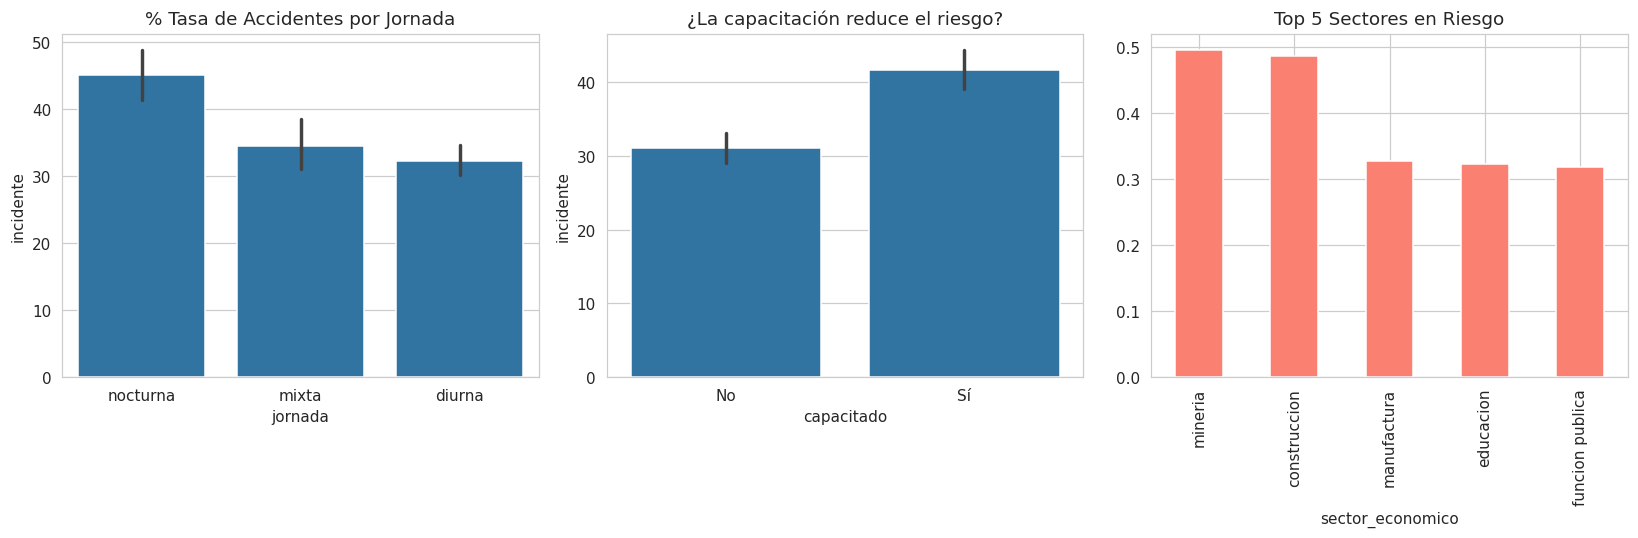

In [ ]:
# Paso 3: Modelado Descriptivo (Visualización de Evidencia)
plt.figure(figsize=(15, 5))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('% Tasa de Accidentes por Jornada')

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No', 'Sí'])
plt.title('¿La capacitación reduce el riesgo?')

# Gráfico 3: Sectores más críticos (Top 5)
plt.subplot(1, 3, 3)
df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Sectores en Riesgo')

plt.tight_layout()
plt.show()

In [ ]:
print("Tasa de accidentes por jornada (%):")
print((df_final.groupby('jornada')['incidente'].mean() * 100).round(1).sort_values(ascending=False))
print("\nTasa de accidentes por capacitación (%):")
print((df_final.groupby('capacitado')['incidente'].mean() * 100).round(1))
print("n por grupo de capacitación:")
print(df_final.groupby('capacitado').size())
print("\nTop 5 sectores en riesgo (%):")
print(top5.round(1))

Tasa de accidentes por jornada (%):
jornada
nocturna    45.0
mixta       34.5
diurna      32.3
Name: incidente, dtype: float64

Tasa de accidentes por capacitación (%):
capacitado
0    31.0
1    41.7
Name: incidente, dtype: float64
n por grupo de capacitación:
capacitado
0    1721
1    1279
dtype: int64

Top 5 sectores en riesgo (%):
sector_economico
mineria            49.6
construccion       48.6
manufactura        32.8
educacion          32.3
funcion publica    31.9
Name: incidente, dtype: float64


## Sección de exploración autónoma
Se profundiza en los factores sugeridos (**antigüedad**, **nivel educativo**, **sistema de gestión**) y en dos hallazgos adicionales que resultaron muy relevantes en este dataset: **tipo de cargo** y **edad**, además de una mirada al tipo de lesión más frecuente.

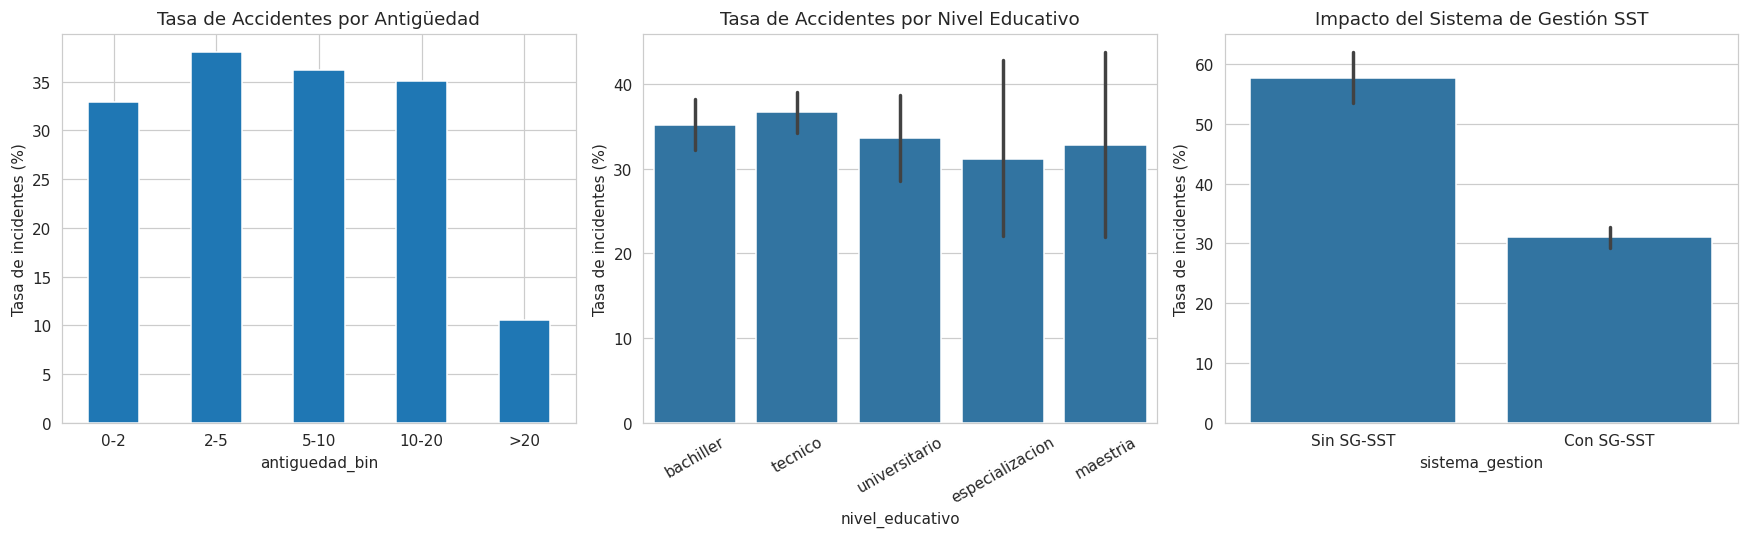

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Antigüedad (agrupada en tramos)
bins = [-0.1, 2, 5, 10, 20, 30]
labels = ['0-2', '2-5', '5-10', '10-20', '>20']
df_final['antiguedad_bin'] = pd.cut(df_final['antiguedad'], bins=bins, labels=labels)
tasa_antig = df_final.groupby('antiguedad_bin', observed=True)['incidente'].mean() * 100
tasa_antig.plot(kind='bar', ax=axes[0])
axes[0].set_title('Tasa de Accidentes por Antigüedad')
axes[0].set_ylabel('Tasa de incidentes (%)')
axes[0].tick_params(axis='x', rotation=0)

# 2) Nivel educativo
orden_edu = ['bachiller', 'tecnico', 'universitario', 'especializacion', 'maestria']
sns.barplot(data=df_final, x='nivel_educativo', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, order=orden_edu, ax=axes[1])
axes[1].set_title('Tasa de Accidentes por Nivel Educativo')
axes[1].set_ylabel('Tasa de incidentes (%)')
axes[1].tick_params(axis='x', rotation=30)

# 3) Sistema de gestión SST
sns.barplot(data=df_final, x='sistema_gestion', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, ax=axes[2])
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Sin SG-SST', 'Con SG-SST'])
axes[2].set_title('Impacto del Sistema de Gestión SST')
axes[2].set_ylabel('Tasa de incidentes (%)')

plt.tight_layout()
plt.show()

In [ ]:
print("Tasa de accidentes por antigüedad (%):")
print(tasa_antig.round(1))
print("\nTasa de accidentes por nivel educativo (%):")
print((df_final.groupby('nivel_educativo')['incidente'].mean() * 100).round(1).sort_values(ascending=False))
print("\nTasa de accidentes según sistema de gestión (%):")
print((df_final.groupby('sistema_gestion')['incidente'].mean() * 100).round(1))

Tasa de accidentes por antigüedad (%):
antiguedad_bin
0-2      33.0
2-5      38.0
5-10     36.1
10-20    35.0
>20      10.5
Name: incidente, dtype: float64

Tasa de accidentes por nivel educativo (%):
nivel_educativo
tecnico            36.7
bachiller          35.1
universitario      33.6
maestria           32.8
especializacion    31.2
Name: incidente, dtype: float64

Tasa de accidentes según sistema de gestión (%):
sistema_gestion
0    57.6
1    31.1
Name: incidente, dtype: float64


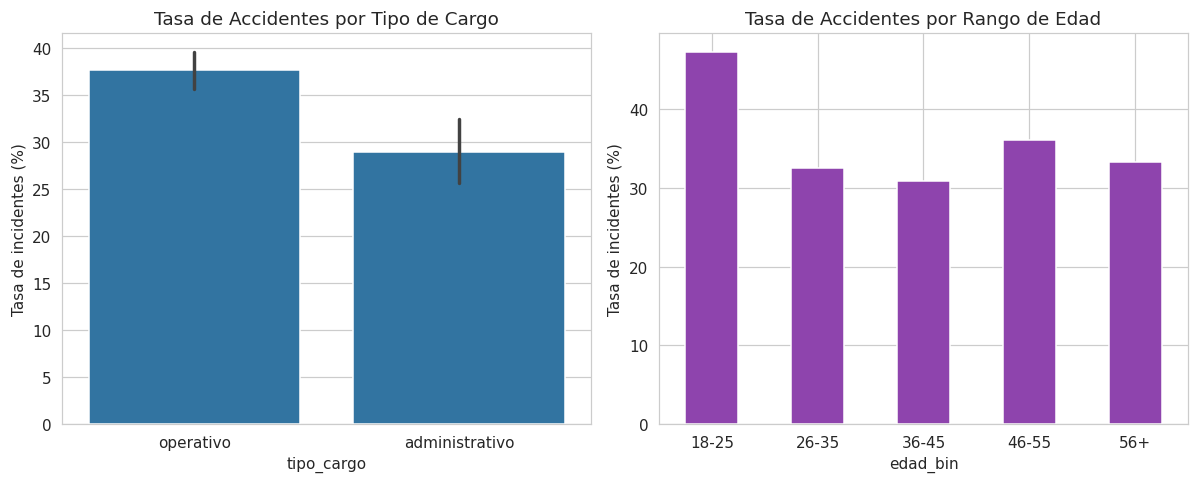

Tasa por tipo de cargo (%):
tipo_cargo
administrativo    28.9
operativo         37.6
Name: incidente, dtype: float64

Tasa por rango de edad (%):
edad_bin
18-25    47.3
26-35    32.6
36-45    31.0
46-55    36.1
56+      33.3
Name: incidente, dtype: float64


In [ ]:
# Gráficos adicionales: cargo y edad
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=df_final, x='tipo_cargo', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, ax=axes[0])
axes[0].set_title('Tasa de Accidentes por Tipo de Cargo')
axes[0].set_ylabel('Tasa de incidentes (%)')

bins_e = [17, 25, 35, 45, 55, 100]
labels_e = ['18-25', '26-35', '36-45', '46-55', '56+']
df_final['edad_bin'] = pd.cut(df_final['edad'], bins=bins_e, labels=labels_e)
tasa_edad = df_final.groupby('edad_bin', observed=True)['incidente'].mean() * 100
tasa_edad.plot(kind='bar', ax=axes[1], color='#8E44AD')
axes[1].set_title('Tasa de Accidentes por Rango de Edad')
axes[1].set_ylabel('Tasa de incidentes (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Tasa por tipo de cargo (%):")
print((df_final.groupby('tipo_cargo')['incidente'].mean() * 100).round(1))
print("\nTasa por rango de edad (%):")
print(tasa_edad.round(1))

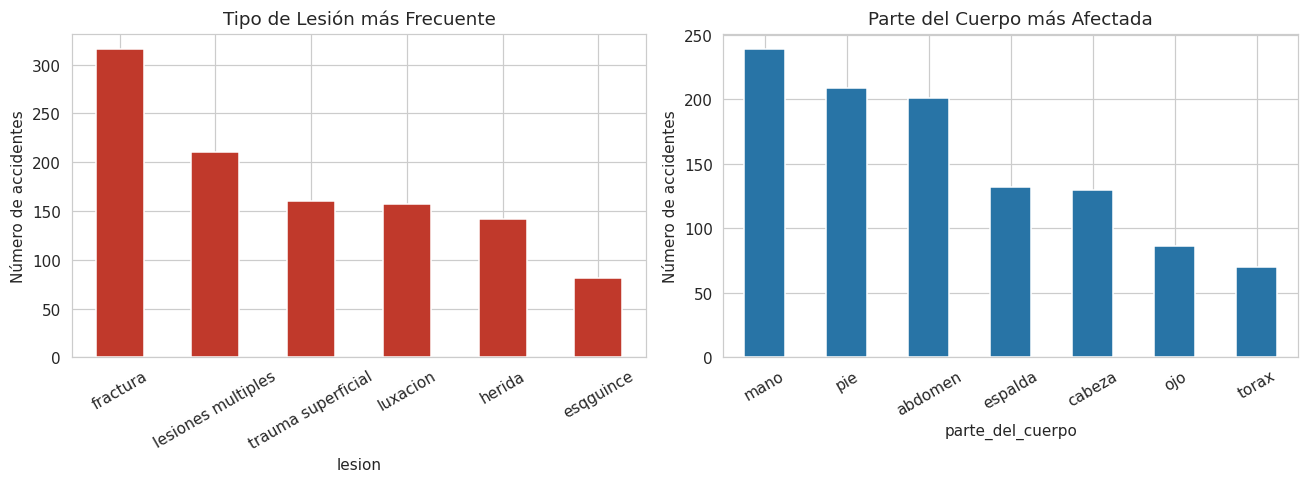

In [ ]:
# Gráfico adicional: tipo de lesión y parte del cuerpo más afectada (solo accidentes ocurridos)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df_accidentes['lesion'].value_counts().plot(kind='bar', ax=axes[0], color='#C0392B')
axes[0].set_title('Tipo de Lesión más Frecuente')
axes[0].set_ylabel('Número de accidentes')
axes[0].tick_params(axis='x', rotation=30)

df_accidentes['parte_del_cuerpo'].value_counts().plot(kind='bar', ax=axes[1], color='#2874A6')
axes[1].set_title('Parte del Cuerpo más Afectada')
axes[1].set_ylabel('Número de accidentes')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Segmentos críticos combinados
crit1 = df_final[(df_final.sector_economico.isin(['mineria', 'construccion'])) & (df_final.sistema_gestion == 0)]
resto1 = df_final[~((df_final.sector_economico.isin(['mineria', 'construccion'])) & (df_final.sistema_gestion == 0))]
print(f"Segmento CRÍTICO (minería/construcción SIN SG-SST): {crit1['incidente'].mean()*100:.1f}%  (n={len(crit1)})")
print(f"Resto de trabajadores: {resto1['incidente'].mean()*100:.1f}%  (n={len(resto1)})")

crit2 = df_final[(df_final.jornada == 'nocturna') & (df_final.tipo_cargo == 'operativo')]
resto2 = df_final[~((df_final.jornada == 'nocturna') & (df_final.tipo_cargo == 'operativo'))]
print(f"\nSegmento operativo + jornada nocturna: {crit2['incidente'].mean()*100:.1f}%  (n={len(crit2)})")
print(f"Resto de trabajadores: {resto2['incidente'].mean()*100:.1f}%  (n={len(resto2)})")

Segmento CRÍTICO (minería/construcción SIN SG-SST): 65.6%  (n=253)
Resto de trabajadores: 32.8%  (n=2747)

Segmento operativo + jornada nocturna: 48.9%  (n=507)
Resto de trabajadores: 32.9%  (n=2493)


## Análisis

**1. Mapeo Metodológico (CRISP-DM: Data Understanding & Data Preparation)
En el marco de la metodología CRISP-DM, se ejecutó un proceso riguroso de exploración y preparación de datos para responder al desafío de accidentalidad del conglomerado (150 empresas)** :
Data Understanding (Comprensión de Datos): Se auditaron y cargaron tres fuentes de información: trabajadores.csv (3,000 registros demográficos, laborales y de capacitación), empresas.csv (150 registros con sector económico y estado del Sistema de Gestión de Seguridad y Salud en el Trabajo - SGSST) y accidentes.csv (1,067 registros históricos de incidentes laborales).  

**Data Preparation (Preparación de Datos)**: Se realizó un procedimiento de Triple Join continuo. En primer lugar, se combinó trabajadores.csv con empresas.csv vinculando el atributo empresa con id_empresa. En segundo lugar, se aplicó un Left Join con accidentes.csv sobre la clave de coincidencia id_trabajador para conservar la totalidad del personal (tanto afectados como no accidentados). Finalmente, se derivó la variable binaria objetivo incidente (1 = Tuvo accidente, 0 = No tuvo accidente) basada en la presencia de id_accidente, generando una Tabla Maestra de Riesgos de 3,000 trabajadores y una tasa media global de accidentalidad del 35.57%.  

**2. Diagnóstico de factores de riesgo.** La jornada **nocturna** es la más peligrosa: **44.96%** de tasa de accidentalidad, frente a **34.49%** en jornada mixta y **32.26%** en diurna. Respecto a la capacitación, el dato es contraintuitivo: los trabajadores **capacitados presentan una tasa mayor** (41.7%) que los no capacitados (31.0%). Este dato a pesar de ser curioso ya que al tener mas personal capacitado "debería" haber menos accidentes, lo que puede suceder en este caso es que los capacitados son trabajadores mas expuestos al riesgo.

**3. Hallazgos adicionales (exploración autónoma).** El factor con el efecto más fuerte y más confiable del dataset es el **Sistema de Gestión SST**: sin él, la tasa de accidentalidad es **57.6%**; con él, **31.1%** (-46% relativo). Minería (49.6%) y Construcción (48.6%) son los sectores más críticos, y su combinación con la ausencia de SG-SST dispara la tasa a **65.6%** (vs. 32.8% en el resto de la población). El cargo **operativo** (37.6%) es más riesgoso que el administrativo (28.9%), y los trabajadores más **jóvenes (18-25 años)** presentan la tasa más alta (47.3%), consistente con menor experiencia. Las lesiones más comunes son **fracturas** (316 casos) y **lesiones múltiples** (211), concentradas en manos y pies.

**4. Recomendación ERP (Insight Accionable).**
**Regla de Bloqueo de Malla Horaria y Alerta Preventiva Nocturna:**

Si un trabajador de rol operativo perteneciente a los sectores de Minería o Construcción es asignado a la jornada nocturna, el ERP debe verificar automáticamente si la empresa cuenta con sistema_gestion = 1. De lo contrario, el sistema bloqueará la asignación de turnos nocturnos hasta regularizar el sistema de gestión.

**Regla de Recertificación Práctica Obligatoria (Sistema Restrictivo de Capacitación):**

Modificar el indicador de "capacitado" de un simple registro asistencial a un esquema de evaluación por competencias en campo. El ERP generará una alerta de capacitación práctica obligatoria y bloqueará permisos para tareas de alto riesgo a todo personal operativo con más de 1 año de antigüedad que no haya completado un entrenamiento práctico validado en sitio.

## Conclusiones

De acuerdo a las graficas de visualización y a las hechas de forma autonoma, con el fin de encontrar mas sentido en el Dataset y revisar cuales son los datos mas fuertes, se puede concluir lo siguiente:

- El **Sistema de Gestión SST es el factor protector más fuerte y consistente** del dataset. Exigirlo como estándar mínimo, en particular en Minería y Construcción, es la palanca de mayor impacto disponible.
- La combinación **sector de alto riesgo (minería/construcción) + ausencia de SG-SST** es el segmento más peligroso identificado: **65.6%** de accidentalidad, más del doble que el resto de la fuerza laboral.
- La **jornada nocturna** y el **cargo operativo** elevan el riesgo de forma consistente; los trabajadores más jóvenes (18-25 años) también están más expuestos, probablemente por menor experiencia.
- El hallazgo sobre **capacitación** (mayor tasa entre capacitados) es un llamado de atención metodológico: **no se debe usar como evidencia para reducir la capacitación**. Se recomienda registrar la fecha de la capacitación y la fecha del accidente en futuras versiones del dataset, para poder establecer la secuencia temporal y evaluar el efecto real de la capacitación.


